# Bayesian Classifier from Scratch

This notebook demonstrates a Bayesian classifier for a binary classification problem using artificially generated Gaussian data.

The implementation follows the mathematical derivation from the theory notes, but the original code is organized into small functions so that each step is easier to understand and explain.

The goal is not to use high-level machine learning libraries, but to implement the classifier from first principles.


## 1. Problem Definition

We consider two classes in a two-dimensional feature space.

Each class is generated from a multivariate normal distribution:

- Class I has mean vector `M1`
- Class II has mean vector `M2`
- Both classes share the same covariance matrix `Sigma`

Since the covariance matrices are equal, the Bayesian discriminant function becomes linear.

The decision boundary is obtained from:

$$
h(X) = 0
$$

where:

$$
h(X) =
(M_2 - M_1)^T \Sigma^{-1} X
+
\frac{1}{2}
(M_1^T \Sigma^{-1} M_1 - M_2^T \Sigma^{-1} M_2)
$$


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

## 2. Generating Artificial Data

This part follows the original implementation.

We define:

- mean vector for Class I
- mean vector for Class II
- shared covariance matrix
- number of generated samples per class

The generated data is used as the training dataset.


In [39]:
# Parameters of the two Gaussian classes
M1 = np.array([-1, 4])
M2 = np.array([3, 1])

Sigma = np.array([
    [2, -1],
    [-1, 1]
])

N = 200

np.random.seed(0)

In [40]:
def generate_artificial_data(mean_1, mean_2, covariance, n_samples):
    """
    Generates two artificial classes from multivariate normal distributions.

    This follows the original idea:

    y1, y2 -> samples from Class I
    z1, z2 -> samples from Class II
    """
    y1, y2 = np.random.multivariate_normal(mean_1, covariance, n_samples).T
    z1, z2 = np.random.multivariate_normal(mean_2, covariance, n_samples).T

    return y1, y2, z1, z2

In [41]:
y1, y2, z1, z2 = generate_artificial_data(M1, M2, Sigma, N)

print("Shape of Class I feature vector:", y1.shape)
print("Shape of Class II feature vector:", z1.shape)

Shape of Class I feature vector: (200,)
Shape of Class II feature vector: (200,)


In [42]:
def plot_two_classes(y1, y2, z1, z2, title):
    """
    Plots two classes in the x1-x2 feature space.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(y1, y2, '*m', label='Class I')
    plt.plot(z1, z2, 'oc', label='Class II')
    plt.grid(True)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.show()

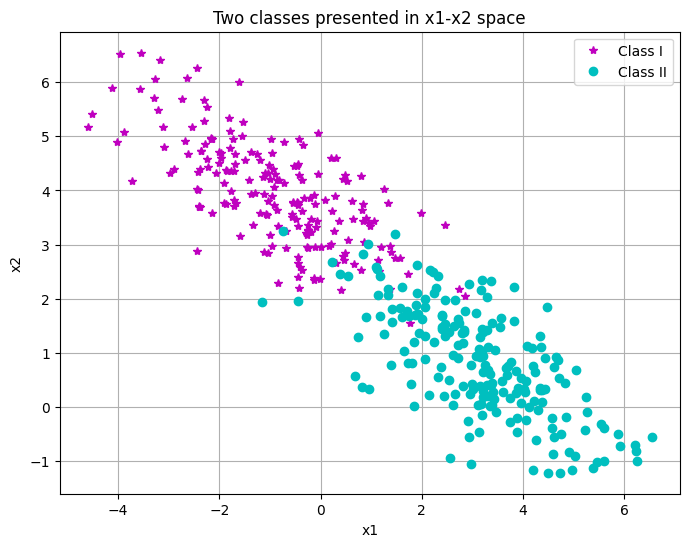

In [43]:
plot_two_classes(
    y1, y2, z1, z2,
    title='Two classes presented in x1-x2 space'
)

### Conclusion

The two generated classes are visible in the two-dimensional feature space.

The classes overlap, which means that perfect classification is not possible. Because of this overlap, some classification error is expected.

This is important because the goal of the Bayesian classifier is not to remove the error completely, but to minimize the expected classification error.


## 3. Discrimination Line Calculation

Since both classes have the same covariance matrix, the discrimination function is linear.

The original code computes:

```python
invSigma = linalg.inv(Sigma)
M3 = M2.T - M1.T
m1 = M3[0]
m2 = M3[1]
```

These values come directly from the theoretical expression:

$$
(M_2 - M_1)^T \Sigma^{-1} X
$$

For a two-dimensional vector:

$$
X =
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
$$

the decision boundary is obtained by setting:

$$
h(X) = 0
$$

and solving for `x2`.


In [44]:
def calculate_discrimination_parameters(mean_1, mean_2, covariance):
    """
    Calculates the parameters used in the linear discriminant function.

    This function is intentionally close to the original code:

    invSigma = inverse of covariance matrix
    M3 = M2 - M1
    m1, m2 = components of M3

    The constant term is:

    0.5 * (M1.T * invSigma * M1 - M2.T * invSigma * M2)
    """
    invSigma = linalg.inv(covariance)

    M3 = mean_2.T - mean_1.T
    m1 = M3[0]
    m2 = M3[1]

    constant = 0.5 * (
        mean_1.T.dot(invSigma).dot(mean_1)
        - mean_2.T.dot(invSigma).dot(mean_2)
    )

    return invSigma, M3, m1, m2, constant

In [45]:
invSigma, M3, m1, m2, constant = calculate_discrimination_parameters(M1, M2, Sigma)

print("Inverse covariance matrix:")
print(invSigma)

print("\nM3 = M2 - M1:")
print(M3)

print("\nm1:", m1)
print("m2:", m2)

print("\nConstant term:")
print(constant)

Inverse covariance matrix:
[[1. 1.]
 [1. 2.]]

M3 = M2 - M1:
[ 4 -3]

m1: 4
m2: -3

Constant term:
4.0


In [46]:
def calculate_discrimination_line(x1_values, invSigma, m1, m2, constant):
    """
    Calculates x2 values for the discrimination line.

    The discriminant function is:

    h(x1, x2) =
    (m1*invSigma[0,0] + m2*invSigma[1,0]) * x1
    +
    (m1*invSigma[0,1] + m2*invSigma[1,1]) * x2
    +
    constant

    The decision boundary is h(x1, x2) = 0.

    Solving for x2 gives the formula below.
    """
    coefficient_x1 = m1 * invSigma[0, 0] + m2 * invSigma[1, 0]
    coefficient_x2 = m1 * invSigma[0, 1] + m2 * invSigma[1, 1]

    x2_values = (-coefficient_x1 * x1_values - constant) / coefficient_x2

    return x2_values

In [47]:
x1_line = np.arange(-5, 7, 0.1)
x2_line = calculate_discrimination_line(x1_line, invSigma, m1, m2, constant)

In [48]:
def plot_classes_with_discrimination_line(y1, y2, z1, z2, x1_line, x2_line, title):
    """
    Plots two classes together with the discrimination line.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(y1, y2, '*m', label='Class I')
    plt.plot(z1, z2, 'oc', label='Class II')
    plt.plot(x1_line, x2_line, 'k--', label='Discrimination line')
    plt.grid(True)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.show()

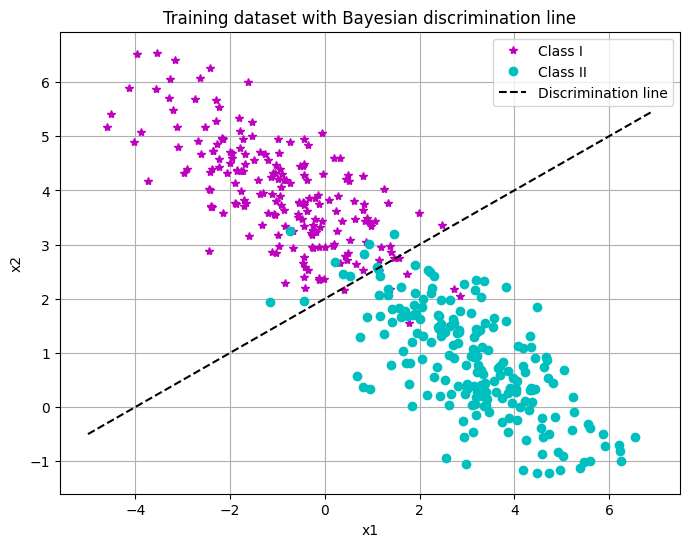

In [49]:
plot_classes_with_discrimination_line(
    y1, y2, z1, z2,
    x1_line, x2_line,
    title='Training dataset with Bayesian discrimination line'
)

### Conclusion

The discrimination line separates the two Gaussian classes according to the Bayesian minimal error decision rule.

Because the covariance matrices are equal, the boundary is linear.

However, the classes overlap, so some points from Class I and Class II are expected to appear on the wrong side of the decision boundary.


## 4. Generating New Test Data

To evaluate the classifier, new test data is generated.

The test data is not identical to the training data. The mean vectors and covariance matrix are slightly changed, which makes the evaluation more realistic.

This helps us check whether the classifier can correctly classify new samples, not only the samples used for visualization and boundary construction.


In [50]:
# Parameters for new test data
M11 = np.array([-1.1, 4.1])
M21 = np.array([3.03, 1.02])

Sigma1 = np.array([
    [2.1, -1.1],
    [-1.1, 1.1]
])

N1 = 50

In [51]:
def generate_test_data(mean_1_test, mean_2_test, covariance_test, n_samples):
    """
    Generates test samples for both classes.

    y11, y21 -> test samples from Class I
    z11, z21 -> test samples from Class II
    """
    y11, y21 = np.random.multivariate_normal(mean_1_test, covariance_test, n_samples).T
    z11, z21 = np.random.multivariate_normal(mean_2_test, covariance_test, n_samples).T

    return y11, y21, z11, z21

In [52]:
y11, y21, z11, z21 = generate_test_data(M11, M21, Sigma1, N1)

In [53]:
def plot_training_and_test_data(
    y1, y2, z1, z2,
    y11, y21, z11, z21,
    x1_line, x2_line,
    title
):
    """
    Plots training data, test data and the discrimination line.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(y1, y2, '*m', label='Training Class I')
    plt.plot(z1, z2, 'oc', label='Training Class II')

    plt.plot(y11, y21, '*r', label='Test Class I')
    plt.plot(z11, z21, '*g', label='Test Class II')

    plt.plot(x1_line, x2_line, 'k--', label='Discrimination line')

    plt.grid(True)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.show()

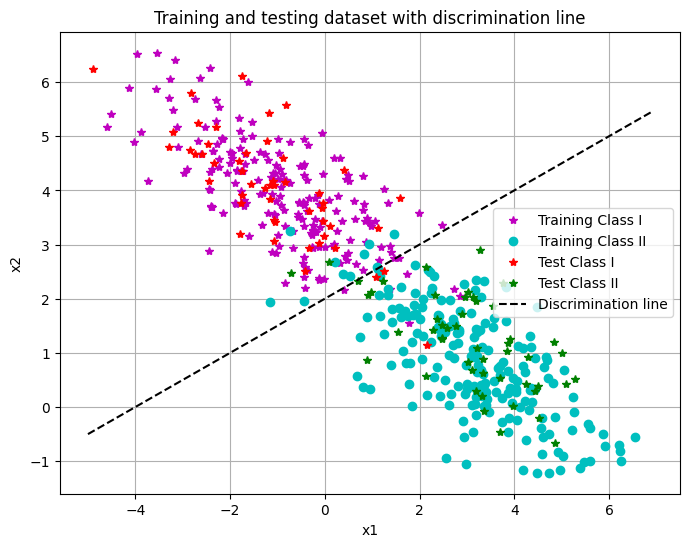

In [54]:
plot_training_and_test_data(
    y1, y2, z1, z2,
    y11, y21, z11, z21,
    x1_line, x2_line,
    title='Training and testing dataset with discrimination line'
)

In [55]:
def plot_test_data_with_discrimination_line(y11, y21, z11, z21, x1_line, x2_line, title):
    """
    Plots only test data with the discrimination line.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(y11, y21, '*r', label='Test Class I')
    plt.plot(z11, z21, '*g', label='Test Class II')
    plt.plot(x1_line, x2_line, 'k--', label='Discrimination line')
    plt.grid(True)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.show()

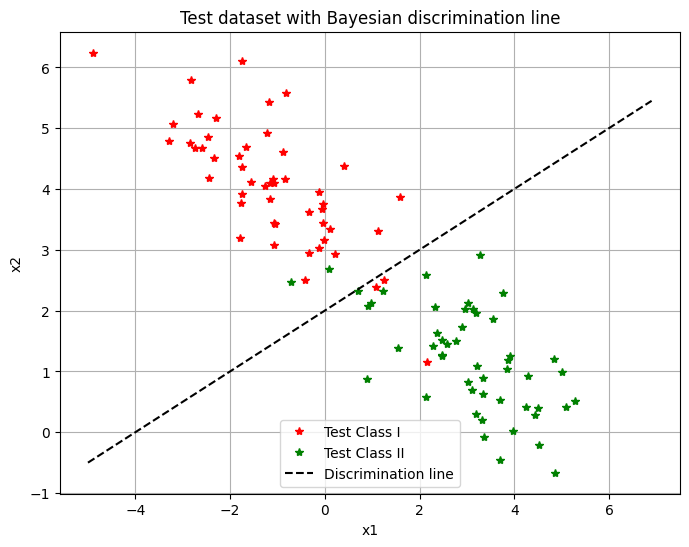

In [56]:
plot_test_data_with_discrimination_line(
    y11, y21, z11, z21,
    x1_line, x2_line,
    title='Test dataset with Bayesian discrimination line'
)

### Conclusion

The test samples follow a similar distribution pattern as the training samples, but they are generated independently.

This allows us to evaluate whether the discrimination line generalizes to new data.

Some test samples are expected to be incorrectly classified because the two class distributions overlap.


## 5. Calculating Classification Error

The discriminant function is evaluated on the test data.

The decision rule is:

- if `h(X) < 0`, classify the point as Class I
- if `h(X) > 0`, classify the point as Class II

Therefore:

- Type I error: sample from Class I classified as Class II
- Type II error: sample from Class II classified as Class I

The total Bayesian error for equal prior probabilities is:

$$
P = 0.5 \cdot \epsilon_1 + 0.5 \cdot \epsilon_2
$$

and accuracy is:

$$
T = (1 - P) \cdot 100
$$


In [57]:
def calculate_h_values(x1_points, x2_points, invSigma, m1, m2, constant):
    """
    Calculates values of the discriminant function h(X).

    This is the same formula used in the original code:

    h =
    (m1*invSigma[0,0] + m2*invSigma[1,0]) * x1
    +
    (m1*invSigma[0,1] + m2*invSigma[1,1]) * x2
    +
    constant
    """
    coefficient_x1 = m1 * invSigma[0, 0] + m2 * invSigma[1, 0]
    coefficient_x2 = m1 * invSigma[0, 1] + m2 * invSigma[1, 1]

    h_values = coefficient_x1 * x1_points + coefficient_x2 * x2_points + constant

    return h_values

In [58]:
def count_type_1_errors(h_values_class_1):
    """
    Counts Type I errors.

    Type I error:
    A sample from Class I is classified as Class II.

    Since Class I corresponds to h(X) < 0,
    an error occurs when h(X) > 0.
    """
    error1 = 0

    for i in range(len(h_values_class_1)):
        if h_values_class_1[i] > 0:
            error1 = error1 + 1

    return error1


def count_type_2_errors(h_values_class_2):
    """
    Counts Type II errors.

    Type II error:
    A sample from Class II is classified as Class I.

    Since Class II corresponds to h(X) > 0,
    an error occurs when h(X) < 0.
    """
    error2 = 0

    for i in range(len(h_values_class_2)):
        if h_values_class_2[i] < 0:
            error2 = error2 + 1

    return error2

In [59]:
# First class test samples
x1p1 = y11
x2p1 = y21

h11 = calculate_h_values(x1p1, x2p1, invSigma, m1, m2, constant)
error1 = count_type_1_errors(h11)

# Second class test samples
x1p2 = z11
x2p2 = z21

h21 = calculate_h_values(x1p2, x2p2, invSigma, m1, m2, constant)
error2 = count_type_2_errors(h21)

print("Type I errors:", error1)
print("Type II errors:", error2)

Type I errors: 3
Type II errors: 2


In [60]:
def calculate_accuracy(error1, error2, n_test_samples):
    """
    Calculates classification error and accuracy.

    Eps1 -> Type I error probability
    Eps2 -> Type II error probability
    P    -> total Bayesian error for equal priors
    T    -> classification accuracy
    """
    Eps1 = error1 / n_test_samples
    Eps2 = error2 / n_test_samples

    P = 0.5 * Eps1 + 0.5 * Eps2
    T = (1 - P) * 100

    return Eps1, Eps2, P, T

In [61]:
Eps1, Eps2, P, T = calculate_accuracy(error1, error2, N1)

print("Type I error probability:", Eps1)
print("Type II error probability:", Eps2)
print("Total Bayesian error:", P)
print("Classification accuracy:", T, "%")

Type I error probability: 0.06
Type II error probability: 0.04
Total Bayesian error: 0.05
Classification accuracy: 95.0 %


### Final Conclusion

The Bayesian classifier achieved high accuracy on the generated test data.

The classifier is based directly on the theoretical discrimination function for two Gaussian classes with equal covariance matrices.

The most important observations are:

- The model uses the mean vectors and covariance matrix of the classes.
- Since both classes share the same covariance matrix, the decision boundary is linear.
- Classification errors occur because the two Gaussian distributions overlap.
- Type I and Type II errors provide a more detailed view of classifier performance than accuracy alone.
- The implementation follows the mathematical derivation step by step, without relying on high-level machine learning libraries.

This makes the project useful as an educational and portfolio example of implementing a Bayesian classifier from scratch.


# 6. Second Classification Problem - Iris Dataset

In this section, the Bayesian classifier is applied to the Iris dataset.

Unlike the first classification problem, the covariance matrices are now different.

Because of this:

- the discrimination function is no longer linear
- the decision boundary becomes quadratic
- the classifier can model more complex class distributions

The implementation below closely follows the original derivation and original code structure.


## 6.1 Loading the Iris Dataset

We use:
- petal length
- petal width

for classification.

These features provide better class separation than sepal features.


In [62]:
import sklearn
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

dataset = datasets.load_iris()

X = dataset.data
Y = dataset.target

In [63]:
def plot_iris_petal_features(X):
    """
    Plot Iris dataset using petal length and petal width.
    """

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X[0:50, 2],
        X[0:50, 3],
        c='y',
        marker='*',
        label='Iris Setosa'
    )

    plt.scatter(
        X[50:100, 2],
        X[50:100, 3],
        c='r',
        marker='^',
        label='Iris Versicolor'
    )

    plt.scatter(
        X[100:150, 2],
        X[100:150, 3],
        c='g',
        marker='o',
        label='Iris Virginica'
    )

    plt.xlabel('Petal length')
    plt.ylabel('Petal width')
    plt.title('Iris dataset using petal features')
    plt.legend()
    plt.grid(True)
    plt.show()

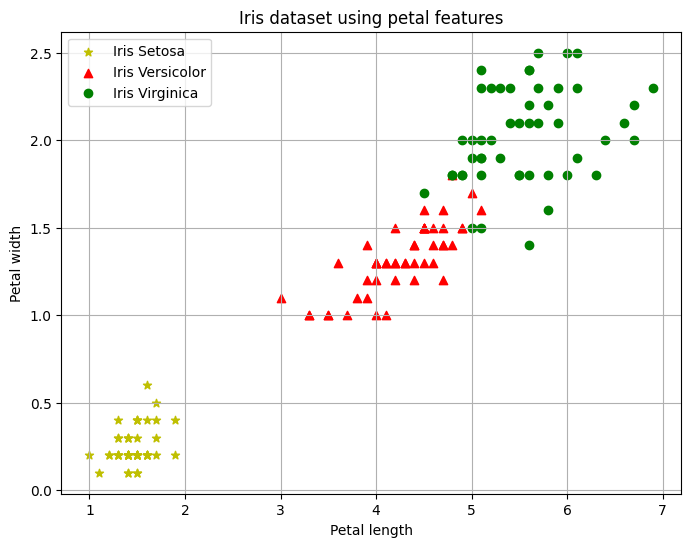

In [64]:
plot_iris_petal_features(X)

### Conclusion

Using petal length and petal width, Iris Setosa is clearly separated from the other classes.

However, Versicolor and Virginica still partially overlap, making the classification problem more difficult.


## 6.2 Feature Overlap Visualization

To better understand the importance of feature selection, we also visualize:

- sepal length
- sepal width

These features create significantly stronger overlap between classes.


In [65]:
def plot_iris_sepal_features(X):
    """
    Plot Iris dataset using sepal length and sepal width.
    """

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X[0:50, 0],
        X[0:50, 1],
        c='y',
        marker='*',
        label='Iris Setosa'
    )

    plt.scatter(
        X[50:100, 0],
        X[50:100, 1],
        c='r',
        marker='^',
        label='Iris Versicolor'
    )

    plt.scatter(
        X[100:150, 0],
        X[100:150, 1],
        c='g',
        marker='o',
        label='Iris Virginica'
    )

    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.title('Iris dataset using sepal features')
    plt.legend()
    plt.grid(True)
    plt.show()

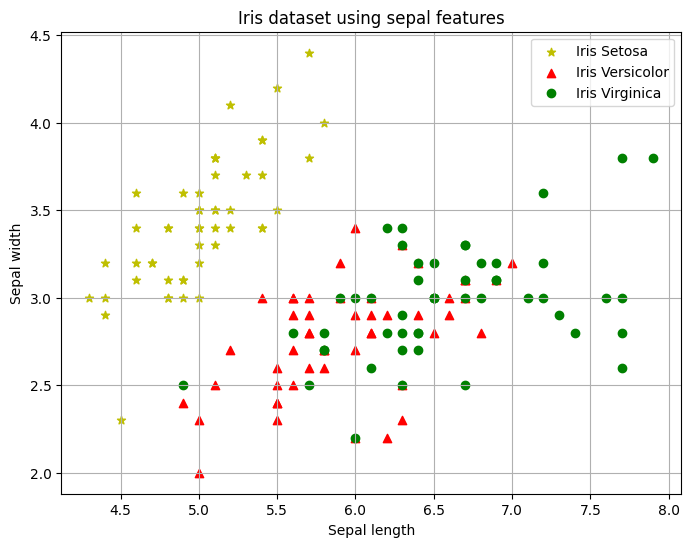

In [66]:
plot_iris_sepal_features(X)

### Conclusion

Compared to petal features, sepal features produce much stronger overlap between classes.

This demonstrates an important machine learning concept:

> Feature selection directly affects classification performance.


## 6.3 Preparing Data for Bayesian Classification

The classification problem is divided into two binary problems:

1. Setosa vs Versicolor
2. Versicolor vs Virginica

For each class we calculate:
- mean vector
- covariance matrix
- inverse covariance matrix

These quantities directly appear in the theoretical discrimination function.


In [67]:
# Petal features
X1 = X[0:50, 2:4]
X2 = X[50:100, 2:4]
X3 = X[100:150, 2:4]

# Covariance matrices
sigma1 = np.cov(X1.T)
sigma2 = np.cov(X2.T)
sigma3 = np.cov(X3.T)

# Inverse covariance matrices
invSigma1 = linalg.inv(sigma1)
invSigma2 = linalg.inv(sigma2)
invSigma3 = linalg.inv(sigma3)

# Mean vectors
M1 = np.mean(X1, axis=0)
M2 = np.mean(X2, axis=0)
M3 = np.mean(X3, axis=0)

print("Mean vector of Setosa:")
print(M1)

print("\nMean vector of Versicolor:")
print(M2)

print("\nMean vector of Virginica:")
print(M3)

Mean vector of Setosa:
[1.462 0.246]

Mean vector of Versicolor:
[4.26  1.326]

Mean vector of Virginica:
[5.552 2.026]


## 6.4 Decision Boundary Calculation

Because covariance matrices are different, the discrimination function becomes quadratic.

The implementation below follows the original formula directly.

No high-level machine learning libraries are used.


In [68]:
def calculate_qda_discriminant(
    x1,
    x2,
    mean_a,
    mean_b,
    inv_covariance_a,
    inv_covariance_b,
    covariance_a,
    covariance_b
):
    """
    Calculates the quadratic discriminant function.

    This implementation intentionally follows the original code structure
    and directly mirrors the theoretical equation.
    """

    term_a = 0.5 * (
        (
            (x1 - mean_a[0]) * inv_covariance_a[0][0]
            + (x2 - mean_a[1]) * inv_covariance_a[1][0]
        ) * (x1 - mean_a[0])
        +
        (
            (x1 - mean_a[0]) * inv_covariance_a[0][1]
            + (x2 - mean_a[1]) * inv_covariance_a[1][1]
        ) * (x2 - mean_a[1])
    )

    term_b = 0.5 * (
        (
            (x1 - mean_b[0]) * inv_covariance_b[0][0]
            + (x2 - mean_b[1]) * inv_covariance_b[1][0]
        ) * (x1 - mean_b[0])
        +
        (
            (x1 - mean_b[0]) * inv_covariance_b[0][1]
            + (x2 - mean_b[1]) * inv_covariance_b[1][1]
        ) * (x2 - mean_b[1])
    )

    log_term = 0.5 * np.log(
        np.linalg.det(covariance_a)
        /
        np.linalg.det(covariance_b)
    )

    h = term_a - term_b + log_term

    return h

In [69]:
Xaxis = np.arange(0, 8, 0.1)
Yaxis = np.arange(0, 3, 0.1)

x1_grid, x2_grid = np.meshgrid(Xaxis, Yaxis)

# Setosa vs Versicolor
h_setosa_versicolor = calculate_qda_discriminant(
    x1_grid,
    x2_grid,
    M1,
    M2,
    invSigma1,
    invSigma2,
    sigma1,
    sigma2
)

# Versicolor vs Virginica
h_versicolor_virginica = calculate_qda_discriminant(
    x1_grid,
    x2_grid,
    M2,
    M3,
    invSigma2,
    invSigma3,
    sigma2,
    sigma3
)

In [70]:
def plot_qda_boundaries(
    X,
    x1_grid,
    x2_grid,
    h_setosa_versicolor,
    h_versicolor_virginica
):
    """
    Plot Iris classes together with QDA decision boundaries.
    """

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X[0:50, 2],
        X[0:50, 3],
        c='y',
        marker='*',
        label='Setosa'
    )

    plt.scatter(
        X[50:100, 2],
        X[50:100, 3],
        c='r',
        marker='^',
        label='Versicolor'
    )

    plt.scatter(
        X[100:150, 2],
        X[100:150, 3],
        c='g',
        marker='o',
        label='Virginica'
    )

    plt.contour(
        x1_grid,
        x2_grid,
        h_setosa_versicolor,
        levels=[0],
        colors='blue'
    )

    plt.contour(
        x1_grid,
        x2_grid,
        h_versicolor_virginica,
        levels=[0],
        colors='red'
    )

    plt.xlabel('Petal length')
    plt.ylabel('Petal width')
    plt.title('Iris species with Bayesian classification boundaries')

    plt.legend()
    plt.grid(True)
    plt.show()

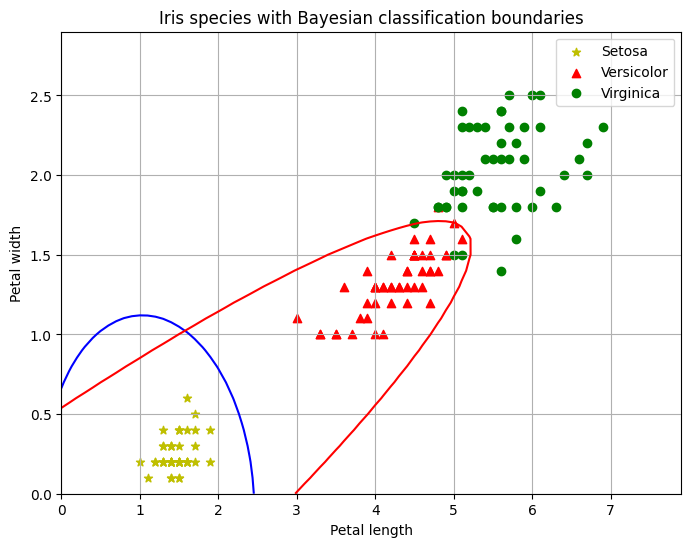

In [71]:
plot_qda_boundaries(
    X,
    x1_grid,
    x2_grid,
    h_setosa_versicolor,
    h_versicolor_virginica
)

### Conclusion

Unlike the first classification problem, the decision boundaries are now nonlinear.

This happens because each class has its own covariance matrix.

The Bayesian classifier therefore adapts more flexibly to the shape of each class distribution.


## 6.5 Classification Accuracy

We now evaluate the classifier for:

1. Setosa vs Versicolor
2. Versicolor vs Virginica

The implementation follows the original code and theoretical decision function.


In [72]:
def count_qda_errors(h_values_class_1, h_values_class_2):
    """
    Counts classification errors for two classes.
    """

    error1 = 0

    for value in h_values_class_1:
        if value > 0:
            error1 = error1 + 1

    error2 = 0

    for value in h_values_class_2:
        if value < 0:
            error2 = error2 + 1

    return error1, error2

In [73]:
# Setosa vs Versicolor

x1p1 = X[0:50, 2]
x2p1 = X[0:50, 3]

h1 = calculate_qda_discriminant(
    x1p1,
    x2p1,
    M1,
    M2,
    invSigma1,
    invSigma2,
    sigma1,
    sigma2
)

x1p2 = X[50:100, 2]
x2p2 = X[50:100, 3]

h2 = calculate_qda_discriminant(
    x1p2,
    x2p2,
    M1,
    M2,
    invSigma1,
    invSigma2,
    sigma1,
    sigma2
)

error1, error2 = count_qda_errors(h1, h2)

Eps1 = error1 / 50.0
Eps2 = error2 / 50.0

P = 0.5 * Eps1 + 0.5 * Eps2
T = (1 - P) * 100

print('Classification of Setosa and Versicolor')
print('Classification accuracy:', T, '%')
print('Number of misclassified Setosa samples:', error1)
print('Number of misclassified Versicolor samples:', error2)

Classification of Setosa and Versicolor
Classification accuracy: 100.0 %
Number of misclassified Setosa samples: 0
Number of misclassified Versicolor samples: 0


In [74]:
# Versicolor vs Virginica

x1p1 = X[50:100, 2]
x2p1 = X[50:100, 3]

h1 = calculate_qda_discriminant(
    x1p1,
    x2p1,
    M2,
    M3,
    invSigma2,
    invSigma3,
    sigma2,
    sigma3
)

x1p2 = X[100:150, 2]
x2p2 = X[100:150, 3]

h2 = calculate_qda_discriminant(
    x1p2,
    x2p2,
    M2,
    M3,
    invSigma2,
    invSigma3,
    sigma2,
    sigma3
)

error1, error2 = count_qda_errors(h1, h2)

Eps1 = error1 / 50.0
Eps2 = error2 / 50.0

P = 0.5 * Eps1 + 0.5 * Eps2
T = (1 - P) * 100

print('Classification of Versicolor and Virginica')
print('Classification accuracy:', T, '%')
print('Number of misclassified Versicolor samples:', error1)
print('Number of misclassified Virginica samples:', error2)

Classification of Versicolor and Virginica
Classification accuracy: 97.0 %
Number of misclassified Versicolor samples: 1
Number of misclassified Virginica samples: 2


## Final Conclusions for the Second Classification Problem

The second classification problem demonstrates a more realistic Bayesian classification scenario.

The most important observations are:

- Different covariance matrices produce nonlinear decision boundaries.
- Bayesian classifiers can adapt to more complex class distributions.
- Petal features provide much better class separation than sepal features.
- Setosa is relatively easy to classify, while Versicolor and Virginica overlap more strongly.
- The implementation follows the theoretical derivation directly and avoids high-level machine learning abstractions.

This project demonstrates both:
- understanding of Bayesian classification theory
- practical implementation from scratch using NumPy and linear algebra
